In [2]:
!pip install numpy matplotlib

In [3]:
import matplotlib.pyplot as plt
import numpy as np


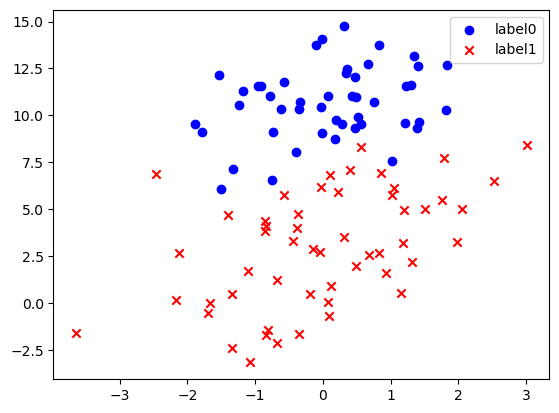

In [4]:
#载入数据
data=np.genfromtxt("LR-testSet.csv",delimiter=',')
x_data=data[:,:-1]  #取到倒数第二列   
y_data=data[:,-1]   #取最后一列,标签

def plot():
    a0=[]   #两类数据的2个特征
    b0=[]
    a1=[]
    b1=[]
    #切分不同类别的数据
    for i in range(len(x_data)):
        if y_data[i]==0:  #正例
            a0.append(x_data[i,0])
            b0.append(x_data[i,1])
        else:  #反例
            a1.append(x_data[i,0])
            b1.append(x_data[i,1])
    #画图
    scatter0=plt.scatter(a0,b0,c='b',marker='o')
    scatter1=plt.scatter(a1,b1,c='r',marker='x')
    #画图例
    plt.legend(handles=[scatter0,scatter1],labels=['label0','label1'],loc='best')
    
plot()
plt.show()

In [5]:
#数据处理，添加偏置项
x_data=data[:,:-1]
y_data=data[:,-1,np.newaxis]
print(x_data.shape)  
print(y_data.shape)

#给样本添加偏置项
X_data=np.concatenate((np.ones((100,1)),x_data),axis=1)  #添加偏置后：[1, x₁, x₂]
print(X_data.shape)

(100, 2)
(100, 1)
(100, 3)


In [ ]:
def sigmoid(x):
    # code here 

    return 

def cost(X, y, weights):
    z = np.dot(X, weights)
    h = sigmoid(z)

    # code here （计算交叉熵损失）
    left = 
    right = 
    return -np.mean(left + right)

def gradAscent(X, y):
    
    lr = 0.001
    epochs = 10000
    cost_list = []
    
    m, n = X.shape
    
    # 初始化权重
    weights = np.zeros((n, 1))  
    
    for i in range(epochs + 1):
        z = np.dot(X, weights)
        h = sigmoid(z)
        
        # code here 计算梯度，x（h-y）/m，注意shape
        gradient =
        # code here 更新梯度 
        weights = 
        
        # 记录损失
        if i % 50 == 0:
            cost_list.append(cost(X, y, weights))
    
    return weights, cost_list

In [ ]:
# 训练模型，得到最终的权值(w0,w1,w2),这里的w0是bias
ws,costList = gradAscent(X_data, y_data)
print(ws)


In [ ]:
# 画决策边界
# 决策边界公式：w0 + w1*x1 + w2*x2 = 0
# 解出 x2 = (-w0 - w1*x1) / w2
plot()
x1_min, x1_max = -4, 3

x1_values = np.linspace(x1_min, x1_max, 100)  #生成x₁坐标：100个等间距的点
x2_values = (-ws[0, 0] - ws[1, 0] * x1_values) / ws[2, 0]  #计算对应的x₂坐标

plt.plot(x1_values, x2_values, 'k-', linewidth=2, label='Decision Boundary')
plt.legend()
plt.show()

In [ ]:
# 画图 loss值的变化
x = np.linspace(0,10000,201)   #201是点的个数
plt.plot(x, costList, c='r')
plt.title('Train')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.show()